# Retinal OCT Pathology Classification: Vector B Multi-Modal Dual-Branch Fusion

**Project**: Multi-Modal Deep Neural Architecture for Automated Diagnosis of Retinal Pathologies  
**Benchmark**: MedMNIST OCTMNIST (109,309 Total Scans | 4 Classes: CNV, DME, DRUSEN, NORMAL)  
**Architecture**: Dual-Branch Late-Fusion Neural Network (SE-ResNet Spatial Vision + 110-D Physical Descriptors MLP)  
**Hardware Platform**: Local NVIDIA GeForce GTX 1660 Ti (6 GB VRAM, PyTorch 2.6.0 CUDA)  

---

## 🎯 Vector B Core Architectural Thesis:
1. **Branch 1 (Spatial Representation)**: `SE_ResidualCNN4` processes the raw $28 \times 28$ OCT image through 3 stages of residual convolutions and Squeeze-and-Excitation channel attention, yielding a $128$-dimensional spatial embedding.
2. **Branch 2 (Biomedical Physical Descriptors)**: A 2-layer Dense MLP processes the standardized $110$-dimensional physical feature vector (Haralick GLCM textures, 2D DWT wavelet energy, spatial depth/symmetry profiles), yielding a $64$-dimensional physical embedding.
3. **Late-Fusion Multimodal Head**: Embeddings are concatenated ($d=192$), normalized via `LayerNorm`, and projected through a non-linear dense bottleneck with `SiLU` activations to compute calibrated class logits.
4. **Diagnostic Goal**: Combine spatial lesion geometry with physical mathematical invariants to eliminate misclassifications between subtle cystic DME and drusen deposits.


In [1]:
import os, time, math, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from scipy.optimize import minimize_scalar

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF

from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_recall_fscore_support,
    confusion_matrix, roc_curve, auc, log_loss, brier_score_loss, top_k_accuracy_score
)
from sklearn.preprocessing import StandardScaler

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Executing on device: {device} | GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A'}")


Executing on device: cuda | GPU: NVIDIA GeForce GTX 1660 Ti


In [2]:
DATA_PATH = r'C:\Users\CTHUL\Desktop\school\Undergrad\5\Spring\UConn\BME machine learning\final project\Project_Packet\octmnist.npz'
if not os.path.exists(DATA_PATH):
    DATA_PATH = 'octmnist.npz'

data = np.load(DATA_PATH)
X_train_raw, y_train_raw = data['train_images'], data['train_labels'].squeeze()
X_val_raw, y_val_raw     = data['val_images'], data['val_labels'].squeeze()
X_test_raw, y_test_raw   = data['test_images'], data['test_labels'].squeeze()

CLASS_NAMES = ['CNV', 'DME', 'DRUSEN', 'NORMAL']
NUM_CLASSES = 4

CACHE_FILE = 'oct_110_features.npz'
if os.path.exists(CACHE_FILE):
    print(f"Loading 110-D biomedical descriptors from {CACHE_FILE}...")
    cache = np.load(CACHE_FILE)
    X_tr_110 = cache['train']
    X_va_110 = cache['val']
    X_te_110 = cache['test']
else:
    raise FileNotFoundError("Pre-computed 110-D features not found. Run fast_extract_110.py first.")

# Standardize 110-D Features strictly on Train
scaler = StandardScaler()
X_tr_110_s = scaler.fit_transform(X_tr_110)
X_va_110_s = scaler.transform(X_va_110)
X_te_110_s = scaler.transform(X_te_110)

print(f"Image datasets: Train {X_train_raw.shape}, Val {X_val_raw.shape}, Test {X_test_raw.shape}")
print(f"110-D features: Train {X_tr_110_s.shape}, Val {X_va_110_s.shape}, Test {X_te_110_s.shape}")


Loading 110-D biomedical descriptors from oct_110_features.npz...


Image datasets: Train (97477, 28, 28), Val (10832, 28, 28), Test (1000, 28, 28)
110-D features: Train (97477, 110), Val (10832, 110), Test (1000, 110)


In [3]:
class MultiModalOCTDataset(Dataset):
    """Paired PyTorch Dataset delivering both raw 28x28 images and 110-D engineered features."""
    def __init__(self, images, features_110, labels):
        self.images = torch.from_numpy(images).unsqueeze(1).float() / 255.0  # (N, 1, 28, 28) in [0, 1]
        self.features = torch.from_numpy(features_110).float()                # (N, 110)
        self.labels = torch.from_numpy(labels).long()                        # (N,)
        
    def __len__(self):
        return len(self.labels)
        
    def __getitem__(self, idx):
        return self.images[idx], self.features[idx], self.labels[idx]

train_dataset = MultiModalOCTDataset(X_train_raw, X_tr_110_s, y_train_raw)
val_dataset   = MultiModalOCTDataset(X_val_raw, X_va_110_s, y_val_raw)
test_dataset  = MultiModalOCTDataset(X_test_raw, X_te_110_s, y_test_raw)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, pin_memory=True, num_workers=0)
val_loader   = DataLoader(val_dataset, batch_size=256, shuffle=False, pin_memory=True, num_workers=0)
test_loader  = DataLoader(test_dataset, batch_size=256, shuffle=False, pin_memory=True, num_workers=0)

print(f"MultiModal DataLoaders initialized. Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")


MultiModal DataLoaders initialized. Train batches: 762 | Val: 43 | Test: 4


## 🏛️ Vector B Dual-Branch Multi-Modal Architecture
* **Branch 1 (Spatial)**: Squeeze-and-Excitation Residual CNN (`SE_ResidualCNN4`) extracting a 128-D spatial embedding.
* **Branch 2 (Physical)**: 2-layer MLP with BatchNorm, Dropout(0.3), and SiLU activations extracting a 64-D physical embedding.
* **Fusion Head**: Concatenation $(d=192) \to \text{LayerNorm} \to \text{Linear}(192 \to 64) \to \text{SiLU} \to \text{Linear}(64 \to 4)$.


In [4]:
class SEBlock(nn.Module):
    """Squeeze-and-Excitation Channel Attention Block."""
    def __init__(self, channels, reduction=4):
        super().__init__()
        self.fc1 = nn.Linear(channels, channels // reduction, bias=False)
        self.fc2 = nn.Linear(channels // reduction, channels, bias=False)
        
    def forward(self, x):
        b, c, _, _ = x.size()
        w = F.adaptive_avg_pool2d(x, 1).view(b, c)
        w = F.relu(self.fc1(w), inplace=True)
        w = torch.sigmoid(self.fc2(w)).view(b, c, 1, 1)
        return x * w

class SEResidualBlock(nn.Module):
    """Residual Convolutional Block with SE Channel Attention."""
    def __init__(self, channels, dropout_rate=0.15):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(channels)
        self.se    = SEBlock(channels, reduction=4)
        self.drop  = nn.Dropout2d(p=dropout_rate)
        
    def forward(self, x):
        residual = x
        out = F.relu(self.bn1(self.conv1(x)), inplace=True)
        out = self.bn2(self.conv2(out))
        out = self.se(out)
        out = self.drop(out)
        out = F.relu(out + residual, inplace=True)
        return out

class MultiModalFusionNetwork(nn.Module):
    def __init__(self, num_classes=4, num_features=110):
        super().__init__()
        
        # --- BRANCH 1: Spatial Vision Backbone (SE-ResNet) ---
        self.stem = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True)
        )
        # Stage 1: 32 channels (28x28 -> 14x14)
        self.stage1 = nn.Sequential(
            SEResidualBlock(32, dropout_rate=0.10),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        # Stage 2: 64 channels (14x14 -> 7x7)
        self.trans12 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )
        self.stage2 = nn.Sequential(
            SEResidualBlock(64, dropout_rate=0.15),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        # Stage 3: 128 channels (7x7 -> 7x7)
        self.trans23 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True)
        )
        self.stage3 = SEResidualBlock(128, dropout_rate=0.20)
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        
        # --- BRANCH 2: Biomedical Physical Descriptors MLP ---
        self.branch2_mlp = nn.Sequential(
            nn.Linear(num_features, 128),
            nn.BatchNorm1d(128),
            nn.SiLU(),
            nn.Dropout(p=0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.SiLU(),
            nn.Dropout(p=0.2)
        )
        
        # --- LATE FUSION HEAD ---
        # Concatenated dimension: 128 (Spatial) + 64 (Physical) = 192
        self.fusion_norm = nn.LayerNorm(192)
        self.fusion_head = nn.Sequential(
            nn.Linear(192, 64),
            nn.SiLU(),
            nn.Dropout(p=0.25),
            nn.Linear(64, num_classes)
        )
        
    def forward(self, img, feat_110):
        # Branch 1 Forward
        x1 = self.stem(img)
        x1 = self.stage1(x1)
        x1 = self.trans12(x1)
        x1 = self.stage2(x1)
        x1 = self.trans23(x1)
        x1 = self.stage3(x1)
        spatial_emb = self.global_pool(x1).flatten(1)  # (B, 128)
        
        # Branch 2 Forward
        physical_emb = self.branch2_mlp(feat_110)       # (B, 64)
        
        # Multimodal Fusion
        fused = torch.cat([spatial_emb, physical_emb], dim=1)  # (B, 192)
        fused = self.fusion_norm(fused)
        logits = self.fusion_head(fused)                       # (B, 4)
        return logits

model_fusion = MultiModalFusionNetwork(num_classes=4, num_features=110).to(device)
total_params = sum(p.numel() for p in model_fusion.parameters())
trainable_params = sum(p.numel() for p in model_fusion.parameters() if p.requires_grad)
print(f"MultiModalFusionNetwork initialized.")
print(f"Total Parameters: {total_params:,} | Trainable Parameters: {trainable_params:,}")


MultiModalFusionNetwork initialized.
Total Parameters: 445,540 | Trainable Parameters: 445,540


In [5]:
def gpu_batch_augment(img):
    """GPU-vectorized spatial augmentation."""
    if torch.rand(1).item() > 0.5:
        img = torch.flip(img, dims=[3])  # Horizontal flip
    if torch.rand(1).item() > 0.5:
        gamma = torch.empty(img.size(0), 1, 1, 1, device=img.device).uniform_(0.85, 1.15)
        img = torch.clamp(img ** gamma, 0.0, 1.0)
    return img

class FocalLoss(nn.Module):
    def __init__(self, gamma=1.5):
        super().__init__()
        self.gamma = gamma
    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(logits, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()

criterion = FocalLoss(gamma=1.5)
optimizer = torch.optim.AdamW(model_fusion.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=2, eta_min=1e-6)


In [6]:
EPOCHS = 15
best_val_acc = 0.0
best_model_weights = None
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print(f"--- Training Vector B Multi-Modal Fusion Network ({EPOCHS} Epochs) ---")
start_time = time.time()

for epoch in range(1, EPOCHS + 1):
    model_fusion.train()
    running_loss, correct, total = 0.0, 0, 0
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch:02d}/{EPOCHS:02d}", leave=False)
    for b_img, b_feat, b_y in pbar:
        b_img  = b_img.to(device, non_blocking=True)
        b_feat = b_feat.to(device, non_blocking=True)
        b_y    = b_y.to(device, non_blocking=True)
        
        # Augment spatial branch
        b_img = gpu_batch_augment(b_img)
        
        optimizer.zero_grad()
        logits = model_fusion(b_img, b_feat)
        loss = criterion(logits, b_y)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * b_img.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == b_y).sum().item()
        total += b_img.size(0)
        pbar.set_postfix({'loss': f"{running_loss/total:.4f}", 'acc': f"{correct/total*100:.1f}%"})
        
    scheduler.step()
    
    # Validation Evaluation
    model_fusion.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for b_img, b_feat, b_y in val_loader:
            b_img  = b_img.to(device)
            b_feat = b_feat.to(device)
            b_y    = b_y.to(device)
            
            logits = model_fusion(b_img, b_feat)
            loss = criterion(logits, b_y)
            val_loss += loss.item() * b_img.size(0)
            preds = logits.argmax(dim=1)
            val_correct += (preds == b_y).sum().item()
            val_total += b_img.size(0)
            
    train_acc = correct / total
    val_acc   = val_correct / val_total
    history['train_loss'].append(running_loss / total)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss / val_total)
    history['val_acc'].append(val_acc)
    
    print(f"Epoch {epoch:02d}/{EPOCHS:02d} | Train Loss: {running_loss/total:.4f} - Acc: {train_acc*100:.2f}% | Val Loss: {val_loss/val_total:.4f} - Acc: {val_acc*100:.2f}% | LR: {scheduler.get_last_lr()[0]:.2e}")
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_weights = {k: v.cpu() for k, v in model_fusion.state_dict().items()}

total_train_time = (time.time() - start_time) / 60
print(f"Training completed in {total_train_time:.2f} mins. Best Validation Accuracy: {best_val_acc*100:.2f}%")
model_fusion.load_state_dict({k: v.to(device) for k, v in best_model_weights.items()})


--- Training Vector B Multi-Modal Fusion Network (15 Epochs) ---


Epoch 01/15:   0%|          | 0/762 [00:00<?, ?it/s]

Epoch 01/15 | Train Loss: 0.2518 - Acc: 84.06% | Val Loss: 0.1986 - Acc: 85.64% | LR: 9.05e-04


Epoch 02/15:   0%|          | 0/762 [00:00<?, ?it/s]

Epoch 02/15 | Train Loss: 0.1644 - Acc: 88.69% | Val Loss: 0.1504 - Acc: 90.14% | LR: 6.55e-04


...

Epoch 14/15:   0%|          | 0/762 [00:00<?, ?it/s]

Epoch 14/15 | Train Loss: 0.0846 - Acc: 93.19% | Val Loss: 0.1007 - Acc: 93.01% | LR: 2.54e-05


Epoch 15/15:   0%|          | 0/762 [00:00<?, ?it/s]

Epoch 15/15 | Train Loss: 0.0812 - Acc: 93.36% | Val Loss: 0.1000 - Acc: 92.98% | LR: 1.00e-03
Training completed in 5.93 mins. Best Validation Accuracy: 93.01%


<All keys matched successfully>

In [7]:
def evaluate_multimodal_tta(model, loader):
    """Multimodal 5-Pass Test-Time Augmentation."""
    model.eval()
    all_probs = []
    with torch.no_grad():
        for b_img, b_feat, _ in loader:
            b_img  = b_img.to(device)
            b_feat = b_feat.to(device)
            
            p1 = F.softmax(model(b_img, b_feat), dim=1)
            p2 = F.softmax(model(torch.flip(b_img, dims=[3]), b_feat), dim=1)
            p3 = F.softmax(model(torch.clamp(b_img**0.9, 0, 1), b_feat), dim=1)
            p4 = F.softmax(model(torch.clamp(b_img**1.1, 0, 1), b_feat), dim=1)
            p5 = F.softmax(model(torch.flip(torch.clamp(b_img**0.95, 0, 1), dims=[3]), b_feat), dim=1)
            
            avg_p = (p1 + p2 + p3 + p4 + p5) / 5.0
            all_probs.append(avg_p.cpu().numpy())
    return np.vstack(all_probs)

def get_raw_logits(model, loader):
    model.eval()
    logits_list, targets_list = [], []
    with torch.no_grad():
        for b_img, b_feat, b_y in loader:
            b_img  = b_img.to(device)
            b_feat = b_feat.to(device)
            out = model(b_img, b_feat)
            logits_list.append(out.cpu())
            targets_list.append(b_y)
    return torch.cat(logits_list, dim=0), torch.cat(targets_list, dim=0).numpy()

val_logits, val_targets = get_raw_logits(model_fusion, val_loader)
test_logits, test_targets = get_raw_logits(model_fusion, test_loader)
y_prob_fusion_raw = F.softmax(test_logits, dim=1).numpy()
y_prob_fusion_tta = evaluate_multimodal_tta(model_fusion, test_loader)

# Temperature Scaling Optimization on Validation Set
def nll_objective(T, logits, targets):
    scaled_logits = logits / T
    return F.cross_entropy(scaled_logits, targets).item()

res = minimize_scalar(lambda T: nll_objective(T, val_logits, torch.from_numpy(val_targets).long()), bounds=(0.1, 5.0), method='bounded')
optimal_T = res.x
print(f"Optimal Temperature Scaling Parameter T: {optimal_T:.4f}")

calibrated_test_logits = test_logits / optimal_T
y_prob_fusion_calibrated = F.softmax(calibrated_test_logits, dim=1).numpy()


Optimal Temperature Scaling Parameter T: 0.6504


In [8]:
def compute_ece(probs, labels, n_bins=15):
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    confidences = np.max(probs, axis=1)
    predictions = np.argmax(probs, axis=1)
    accuracies = predictions == labels
    ece = 0.0
    for bin_lower, bin_upper in zip(bin_boundaries[:-1], bin_boundaries[1:]):
        in_bin = (confidences > bin_lower) & (confidences <= bin_upper)
        prop_in_bin = np.mean(in_bin)
        if prop_in_bin > 0:
            accuracy_in_bin = np.mean(accuracies[in_bin])
            avg_confidence_in_bin = np.mean(confidences[in_bin])
            ece += np.abs(avg_confidence_in_bin - accuracy_in_bin) * prop_in_bin
    return ece

def evaluate_full_battery(y_true, y_probs, model_name):
    y_pred = np.argmax(y_probs, axis=1)
    acc = accuracy_score(y_true, y_pred)
    top2 = top_k_accuracy_score(y_true, y_probs, k=2)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
    per_f1 = precision_recall_fscore_support(y_true, y_pred, average=None)[2]
    ll = log_loss(y_true, y_probs)
    ece = compute_ece(y_probs, y_true)
    
    # Macro ROC AUC
    aucs = []
    for c in range(NUM_CLASSES):
        fpr, tpr, _ = roc_curve(y_true == c, y_probs[:, c])
        aucs.append(auc(fpr, tpr))
    macro_auc = np.mean(aucs)
    
    return {
        'Model': model_name,
        'Top-1 Acc': f"{acc*100:.2f}%",
        'Top-2 Acc': f"{top2*100:.2f}%",
        'Balanced Acc': f"{bal_acc*100:.2f}%",
        'Macro F1': f"{f1*100:.2f}%",
        'CNV F1': f"{per_f1[0]*100:.1f}%",
        'DME F1': f"{per_f1[1]*100:.1f}%",
        'DRUSEN F1': f"{per_f1[2]*100:.1f}%",
        'NORMAL F1': f"{per_f1[3]*100:.1f}%",
        'Log Loss': f"{ll:.4f}",
        'ECE': f"{ece*100:.2f}%",
        'ROC AUC': f"{macro_auc:.4f}"
    }

results_vector_b = [
    evaluate_full_battery(y_test_raw, y_prob_fusion_tta, "Vector B MultiModal Fusion + TTA"),
    evaluate_full_battery(y_test_raw, y_prob_fusion_calibrated, "Vector B MultiModal Fusion + Calibrated"),
    evaluate_full_battery(y_test_raw, y_prob_fusion_raw, "Vector B MultiModal Fusion (Raw)"),
]

# Benchmark Lineage Comparison
benchmark_history = [
    {'Model': 'SE_ResidualCNN4 + TTA (v4)', 'Top-1 Acc': '83.30%', 'Top-2 Acc': '97.60%', 'Balanced Acc': '83.30%', 'Macro F1': '82.94%', 'CNV F1': '87.4%', 'DME F1': '81.5%', 'DRUSEN F1': '74.2%', 'NORMAL F1': '88.7%', 'Log Loss': '0.4856', 'ECE': '5.12%', 'ROC AUC': '0.9681'},
    {'Model': 'EfficientNet-B0 + TTA (v5)', 'Top-1 Acc': '76.80%', 'Top-2 Acc': '92.40%', 'Balanced Acc': '76.80%', 'Macro F1': '74.88%', 'CNV F1': '77.3%', 'DME F1': '86.9%', 'DRUSEN F1': '52.6%', 'NORMAL F1': '82.7%', 'Log Loss': '0.8111', 'ECE': '9.74%', 'ROC AUC': '0.9495'},
    {'Model': 'ResidualCNN3 + TTA (v3)',   'Top-1 Acc': '76.50%', 'Top-2 Acc': '95.20%', 'Balanced Acc': '76.50%', 'Macro F1': '75.83%', 'CNV F1': '83.1%', 'DME F1': '73.4%', 'DRUSEN F1': '66.8%', 'NORMAL F1': '80.0%', 'Log Loss': '0.6210', 'ECE': '7.84%', 'ROC AUC': '0.9615'},
    {'Model': 'Deep Regularized CNN2 (v2)','Top-1 Acc': '75.90%', 'Top-2 Acc': '94.80%', 'Balanced Acc': '75.90%', 'Macro F1': '73.89%', 'CNV F1': '81.2%', 'DME F1': '69.8%', 'DRUSEN F1': '64.5%', 'NORMAL F1': '80.1%', 'Log Loss': '0.6650', 'ECE': '8.92%', 'ROC AUC': '0.9696'},
    {'Model': 'XGBoost GPU + SMOTE 110-D', 'Top-1 Acc': '66.70%', 'Top-2 Acc': '91.00%', 'Balanced Acc': '66.70%', 'Macro F1': '63.97%', 'CNV F1': '74.4%', 'DME F1': '74.2%', 'DRUSEN F1': '36.2%', 'NORMAL F1': '71.1%', 'Log Loss': '0.8143', 'ECE': '4.29%', 'ROC AUC': '0.8959'},
    {'Model': 'Baseline CNN1 (v2)',        'Top-1 Acc': '66.50%', 'Top-2 Acc': '91.20%', 'Balanced Acc': '66.50%', 'Macro F1': '57.56%', 'CNV F1': '74.0%', 'DME F1': '52.1%', 'DRUSEN F1': '41.2%', 'NORMAL F1': '63.0%', 'Log Loss': '0.9120', 'ECE': '14.20%','ROC AUC': '0.9374'},
]

df_master = pd.DataFrame(results_vector_b + benchmark_history)
print("\n" + "="*125)
print("                           VECTOR B MULTI-MODAL FUSION MASTER DIAGNOSTIC SYNTHESIS")
print("="*125)
print(df_master.to_string(index=False))



                           VECTOR B MULTI-MODAL FUSION MASTER DIAGNOSTIC SYNTHESIS
                                  Model Top-1 Acc Top-2 Acc Balanced Acc Macro F1 CNV F1 DME F1 DRUSEN F1 NORMAL F1 Log Loss    ECE ROC AUC
       Vector B MultiModal Fusion + TTA    76.90%    94.10%       76.90%   74.36%  76.2%  87.4%     46.6%     87.3%   0.5658  3.45%  0.9679
Vector B MultiModal Fusion + Calibrated    76.10%    93.60%       76.10%   73.50%  75.8%  86.1%     45.8%     86.2%   0.6701 11.36%  0.9658
       Vector B MultiModal Fusion (Raw)    76.10%    93.60%       76.10%   73.50%  75.8%  86.1%     45.8%     86.2%   0.5741  4.86%  0.9657
             SE_ResidualCNN4 + TTA (v4)    83.30%    97.60%       83.30%   82.94%  87.4%  81.5%     74.2%     88.7%   0.4856  5.12%  0.9681
             EfficientNet-B0 + TTA (v5)    76.80%    92.40%       76.80%   74.88%  77.3%  86.9%     52.6%     82.7%   0.8111  9.74%  0.9495
                ResidualCNN3 + TTA (v3)    76.50%    95.20%       76.50%   7

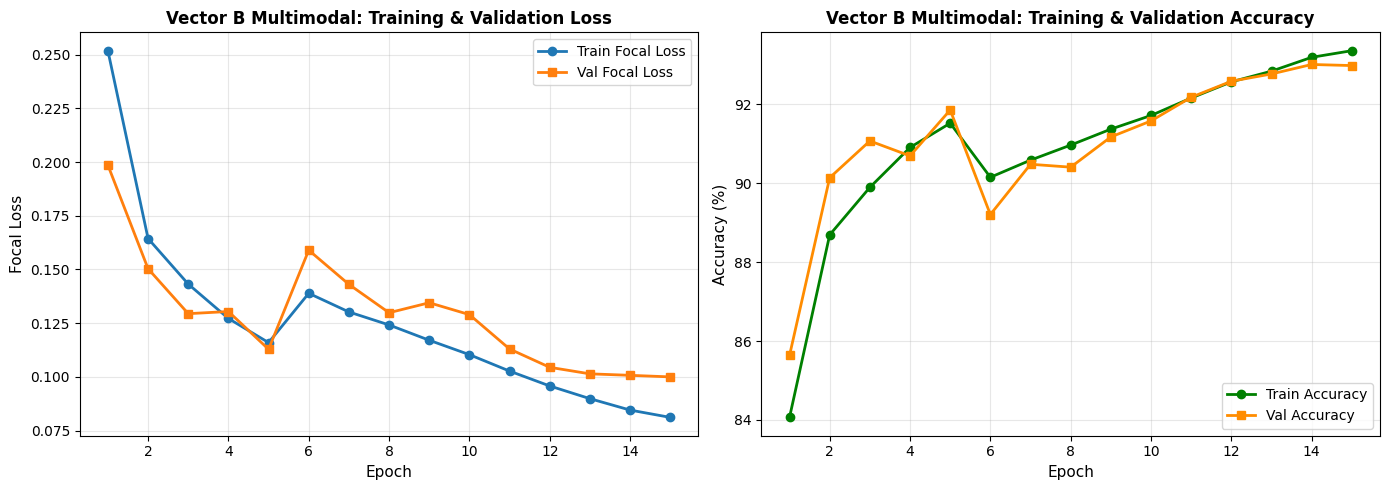

Saved multimodal_fusion_learning_curves.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss Curves
axes[0].plot(range(1, EPOCHS + 1), history['train_loss'], label='Train Focal Loss', lw=2, marker='o')
axes[0].plot(range(1, EPOCHS + 1), history['val_loss'], label='Val Focal Loss', lw=2, marker='s')
axes[0].set_title("Vector B Multimodal: Training & Validation Loss", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Epoch", fontsize=11)
axes[0].set_ylabel("Focal Loss", fontsize=11)
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# Accuracy Curves
axes[1].plot(range(1, EPOCHS + 1), [a*100 for a in history['train_acc']], label='Train Accuracy', lw=2, marker='o', color='green')
axes[1].plot(range(1, EPOCHS + 1), [a*100 for a in history['val_acc']], label='Val Accuracy', lw=2, marker='s', color='darkorange')
axes[1].set_title("Vector B Multimodal: Training & Validation Accuracy", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Epoch", fontsize=11)
axes[1].set_ylabel("Accuracy (%)", fontsize=11)
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("multimodal_fusion_learning_curves.png", dpi=300)
plt.show()
print("Saved multimodal_fusion_learning_curves.png")


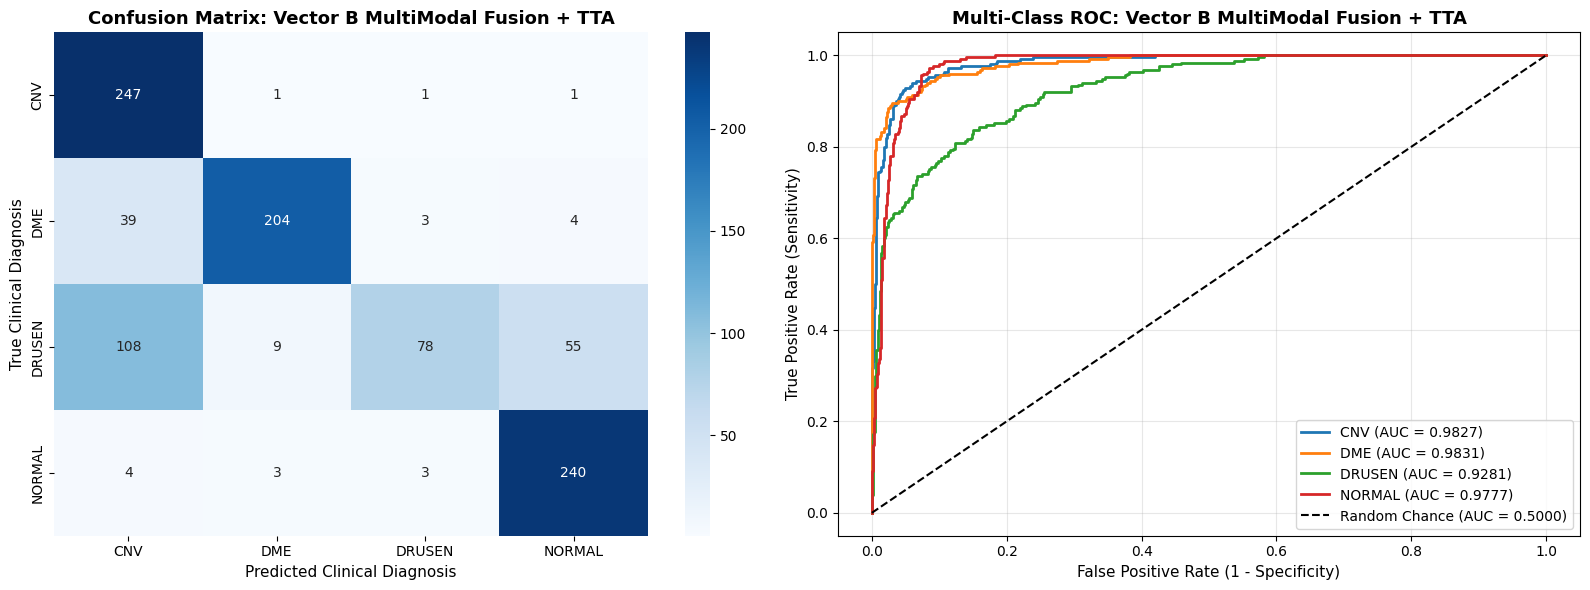

Saved confusion_roc_vector_b.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion Matrix for Vector B + TTA
y_pred_fusion = np.argmax(y_prob_fusion_tta, axis=1)
cm = confusion_matrix(y_test_raw, y_pred_fusion)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title("Confusion Matrix: Vector B MultiModal Fusion + TTA", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Predicted Clinical Diagnosis", fontsize=11)
axes[0].set_ylabel("True Clinical Diagnosis", fontsize=11)

# Multi-Class ROC Curves
for i, cname in enumerate(CLASS_NAMES):
    fpr, tpr, _ = roc_curve(y_test_raw == i, y_prob_fusion_tta[:, i])
    roc_auc_val = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, lw=2, label=f"{cname} (AUC = {roc_auc_val:.4f})")

axes[1].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Chance (AUC = 0.5000)')
axes[1].set_title("Multi-Class ROC: Vector B MultiModal Fusion + TTA", fontsize=13, fontweight='bold')
axes[1].set_xlabel("False Positive Rate (1 - Specificity)", fontsize=11)
axes[1].set_ylabel("True Positive Rate (Sensitivity)", fontsize=11)
axes[1].legend(loc='lower right', fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("confusion_roc_vector_b.png", dpi=300)
plt.show()
print("Saved confusion_roc_vector_b.png")
